## Title: KDDM1 – Homework 2

Name : Md Mehedi Hasan
Id: 12245320

Course: KDDM1 VO 



### Question 1: Feature Engineering
Using the TF-IDF (Term Frequency–Inverse Document Frequency) approach, I extracted features from the talk_text column of the debates_2022.csv dataset. This involved data cleaning and vectorization to obtain the most informative word features.

### Preprocessing Steps
Removed all empty or missing talk transcripts.
Converted text to lowercase and removed punctuation to standardize the content.


In [7]:
# Library
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
import string


In [9]:
debates_df = pd.read_csv(r"C:\Users\mehed\Downloads\debates_2022.csv")

texts = debates_df['talk_text'].dropna()
texts_cleaned = texts.str.lower().apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.8,
    min_df=5,
    max_features=1000
)
X_tfidf = vectorizer.fit_transform(texts_cleaned)
print("TF-IDF feature shape:", X_tfidf.shape)


TF-IDF feature shape: (14497, 1000)


## Q2: Clustering

In this step, I used the KMeans algorithm to group the debate transcripts based on their TF-IDF features.

 I sampled 1,000 documents to test different values of `k` (number of clusters) from 5 to 15.
 For each `k`, I calculated the silhouette score to evaluate clustering quality.
 The best number of clusters was selected based on the highest silhouette score.
 Then, I ran KMeans again on the full dataset using the best `k`.
 Finally, I printed the top 10 important words for each cluster and plotted the silhouette scores.


In [31]:
# Libraries
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.utils import resample
import matplotlib.pyplot as plt
import numpy as np
import os

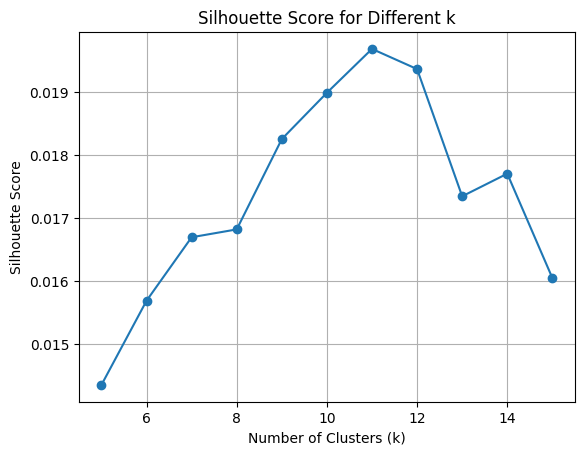

Best number of clusters: 11
Silhouette score: 0.01968681406573233
Cluster 0: european, member, commission, states, eu, union, digital, new, need, important
Cluster 1: climate, food, need, farmers, european, production, sustainable, mr, change, europe
Cluster 2: energy, gas, prices, european, need, renewable, price, crisis, electricity, nuclear
Cluster 3: women, violence, rights, gender, girls, abortion, men, equality, sexual, afghanistan
Cluster 4: agenda, point, session, request, parliament, voting, committee, meeting, 2022, discussion
Cluster 5: ukraine, war, russia, putin, russian, european, ukrainian, people, europe, union
Cluster 6: vote, closed, discussion, statements, written, article, 2022, held, debate, place
Cluster 7: rights, law, human, rule, european, democracy, union, hungary, freedom, eu
Cluster 8: european, mr, president, people, europe, think, parliament, union, want, colleagues
Cluster 9: schengen, romania, bulgaria, croatia, european, area, border, accession, borders

In [35]:
os.environ["OMP_NUM_THREADS"] = "1"       
os.environ["OPENBLAS_NUM_THREADS"] = "1"  
os.environ["MKL_NUM_THREADS"] = "1"       

sample_size = 1000
sample_indices = np.random.choice(X_tfidf.shape[0], sample_size, replace=False)
X_sample = X_tfidf[sample_indices]

cluster_range = range(5, 16)
scores = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_sample)
    score = silhouette_score(X_sample, labels)
    scores.append((k, score))

best_k, best_score = max(scores, key=lambda x: x[1])

final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
final_labels = final_kmeans.fit_predict(X_tfidf)

terms = np.array(vectorizer.get_feature_names_out())
top_words_per_cluster = []
for i in range(best_k):
    cluster_center = final_kmeans.cluster_centers_[i]
    top_indices = cluster_center.argsort()[::-1][:10]
    top_words = terms[top_indices]
    top_words_per_cluster.append((i, top_words.tolist()))

x_vals = [k for k, _ in scores]
y_vals = [s for _, s in scores]
plt.plot(x_vals, y_vals, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different k")
plt.grid(True)
plt.show()

print("Best number of clusters:", best_k)
print("Silhouette score:", best_score)
for cluster_id, words in top_words_per_cluster:
    print(f"Cluster {cluster_id}: {', '.join(words)}")


# Q3: PCA Visualization

In this step, we reduced the TF-IDF features to 2 dimensions using Principal Component Analysis (PCA). The goal was to visualize the clusters obtained from KMeans in 2D space.

 We applied PCA with 2 components on the dense TF-IDF matrix.
 Each data point (debate transcript) was plotted in 2D space.
 Colors represent the clusters predicted by KMeans.
 A colorbar is included to show cluster IDs.
 We also extracted the top 10 terms that contribute most to each PCA component to help interpret the dimensions.

This visualization helps us understand how the high-dimensional data is separated and structured across clusters in a simplified 2D space.


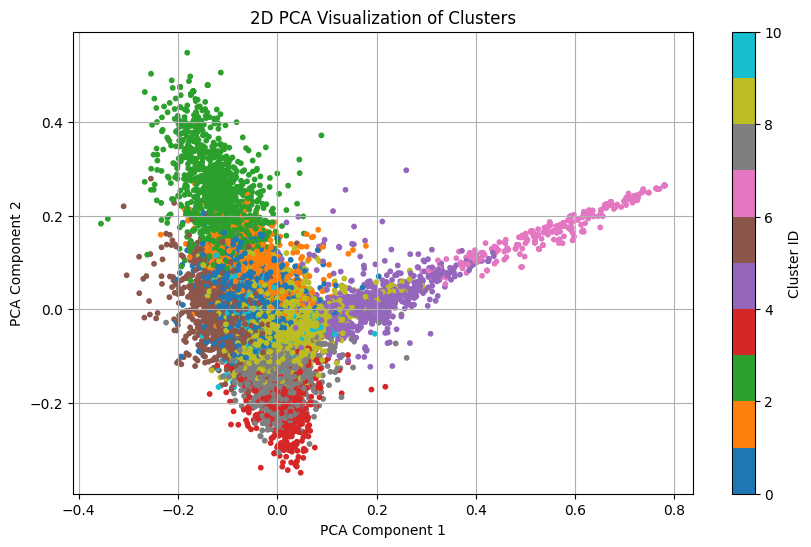

Top PC1 terms: ['vote', 'discussion', 'closed', 'statements', 'written', 'article', '2022', 'agenda', 'held', 'tomorrow']
Top PC2 terms: ['energy', 'gas', 'prices', 'vote', 'discussion', 'closed', 'renewable', 'crisis', 'price', 'statements']


In [68]:
X_pca = PCA(n_components=2).fit_transform(X_tfidf.toarray())

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=final_labels, cmap='tab10', s=10)
plt.title("2D PCA Visualization of Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster ID")
plt.grid(True)
plt.show()
print("Top PC1 terms:", top_terms(pca.components_[0]))
print("Top PC2 terms:", top_terms(pca.components_[1]))

# Q4: Classification – Individual Code Sections
### (a) Preprocessing & Feature Transformation

In this step, we load the chess endgame dataset and create a new target variable by mapping the original win depth into five categories:
 0 for "draw"
 1 for depths from zero to four
 2 for depths five to eight
 3 for depths nine to twelve
 4 for depths thirteen to sixteen

We also encode the file and rank positions of the white king, white rook, and black king using LabelEncoder to convert categorical position data into numerical features.


In [90]:
# Required Library
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV


In [92]:
df = pd.read_csv(r"C:\Users\mehed\Downloads\king_rook_vs_king.csv")

depth_map = {
    'draw': 0,
    'zero': 1, 'one': 1, 'two': 1, 'three': 1, 'four': 1,
    'five': 2, 'six': 2, 'seven': 2, 'eight': 2,
    'nine': 3, 'ten': 3, 'eleven': 3, 'twelve': 3,
    'thirteen': 4, 'fourteen': 4, 'fifteen': 4, 'sixteen': 4
}
df["target"] = df["white_depth_of_win"].map(depth_map)

features = ['white_king_file', 'white_king_rank', 'white_rook_file', 'white_rook_rank',
            'black_king_file', 'black_king_rank']
df_encoded = df[features].apply(LabelEncoder().fit_transform)

X = df_encoded
y = df["target"]


### (b) Model Choice: Random Forest Classifier

We choose a Random Forest Classifier as our model because it handles categorical-like encoded features well, is robust to overfitting, and generally performs well without much tuning. We split the dataset into training and testing sets, then fit the model using the default parameters to get a baseline performance.


In [94]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

### (c) Evaluation Setup

We evaluate the model using `classification_report` which includes accuracy, precision, recall, and F1-score for each class. This helps us understand how well the model is predicting each category of win depth.


In [96]:
y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

           0       0.89      0.85      0.87       549
           1       0.99      0.84      0.91       130
           2       0.94      0.92      0.93       636
           3       0.94      0.94      0.94      2072
           4       0.94      0.96      0.95      2225

    accuracy                           0.94      5612
   macro avg       0.94      0.90      0.92      5612
weighted avg       0.94      0.94      0.94      5612



### (d) Hyperparameter Optimization

To improve the model, we perform grid search with cross-validation to find the best combination of `n_estimators` and `max_depth`. This helps optimize the Random Forest model for accuracy and generalization.


In [98]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best Cross-Validated Score:", grid_search.best_score_)



Best parameters: {'max_depth': None, 'n_estimators': 100}
Best Cross-Validated Score: 0.8978791893397159


### (e) Final Evaluation

After tuning, we evaluate the best model on the test set and display the full classification report in table form. This includes performance metrics for each class and overall accuracy using the best-found parameters.


In [105]:
best_model = grid_search.best_estimator_
y_best_pred = best_model.predict(X_test)

final_report = classification_report(y_test, y_best_pred, output_dict=True)
report_df = pd.DataFrame(final_report).transpose().round(3)
report_df


,precision,recall,f1-score,support
0,0.886,0.847,0.866,549.000
1,0.991,0.838,0.908,130.000
2,0.939,0.918,0.928,636.000
3,0.937,0.941,0.939,2072.000
4,0.942,0.963,0.952,2225.000
accuracy,0.935,0.935,0.935,0.935
macro avg,0.939,0.901,0.919,5612.000
weighted avg,0.935,0.935,0.935,5612.000
